# Lab Assignment — Linear Regression
### Predicting Annual Salary from Professional Experience

## Background

Artificial Intelligence (AI)
-Artificial Intelligence (AI) refers to the simulation of human intelligence by machines. AI systems can perform tasks such as reasoning, learning, problem-solving, and decision-making.

Machine Learning (ML)
-Machine Learning is a subset of AI that enables computers to learn patterns from data and make predictions without being explicitly programmed.

Deep Learning (DL)
-Deep Learning is a specialized branch of ML that uses neural networks with multiple layers to learn complex patterns from large datasets.

Data Science
-Data Science combines statistics, programming, and domain knowledge to extract meaningful insights and support decision-making from data.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


---
## TASK 1 — Simple Linear Regression: Years of Experience → Salary

## Data Retrieval and Collection

Data is retrived from the given csv file.
The Salary dataset is a compact, real-world-inspired tabular file containing exactly two columns: YearsExperience, which records a professional's total years of work experience as a continuous decimal value, and Salary, which records the corresponding annual compensation in US dollars. Both columns are numerical, there are no categorical labels, and the dataset carries no header ambiguity.


In [2]:

df = pd.read_csv('Salary_Data.csv')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (30, 2)

Column Names: ['YearsExperience', 'Salary']

First 5 rows:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


## Data Cleaning

Missing values are handled, Data types are checked.

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check data types
print('\nData types:')
print(df.dtypes)

# Check for duplicates
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
YearsExperience    0
Salary             0
dtype: int64

Data types:
YearsExperience    float64
Salary               int64
dtype: object

Duplicate rows: 0


In [5]:
# Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print('Missing values dropped. New shape:', df.shape)
else:
    print('No missing values found. Dataset is clean.')

# Remove duplicates if any
df.drop_duplicates(inplace=True)
print('Final dataset shape:', df.shape)

No missing values found. Dataset is clean.
Final dataset shape: (30, 2)




The audit shows that the dataset is good to use as it's. The dataset has no missing information no rows are. The two columns have the correct type of numbers. We do not need to do label encoding because there are no categories. We also do not need to fix any numbers in the dataset because there are no unusual values and no values that do not make sense, like a negative number of years of experience or a salary of zero dollars. So the dataset is ready to move on to the step, which is to choose the features that we want to use.

## Feature Design
Select feature to define the dataset for inspections


In [6]:
# Separate feature (X) and label (y)
X = df[['YearsExperience']]   # 2D array required by sklearn
y = df['Salary']

print('Feature shape (X):', X.shape)
print('Label shape (y):', y.shape)
print('\nFeature preview:')
print(X.head())

Feature shape (X): (30, 1)
Label shape (y): (30,)

Feature preview:
   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2


## Algorithm Selection

**Why Simple Linear Regression?**

Linear Regression posits that the target variable ŷ is a linear function of the input feature x:

ŷ = w · x + b

where **w** (the slope or coefficient) captures how much the output changes per unit increase in the input, and **b** (the intercept) shifts the line up or down to fit the observed data.

Three properties make this algorithm well-suited to the task:

1. **Continuous output** — Salary is a real number, not a category. Linear regression natively predicts real-valued outputs.
2. **Expected monotone relationship** — Scatter plots of salary vs. experience routinely show a positive, approximately linear trend. A straight-line model is a faithful approximation of this relationship without unnecessary complexity.
3. **Interpretability** — The learned coefficient w has a direct, concrete meaning: it is the dollar increase in predicted salary for each additional year of experience. For stakeholders who need to explain or audit a model, this transparency is valuable.

Additionally, for a dataset of this size, a low-capacity model like linear regression is *preferable* to a complex one: complex models risk memorising the few available points rather than learning the underlying trend.

## Loss Function Selection

**Mean Squared Error (MSE)**

During training, the algorithm needs a scalar measure of how poorly its current parameter estimates perform. The chosen measure is **Mean Squared Error**:

MSE = (1/n) · Σᵢ (yᵢ − ŷᵢ)²

where yᵢ is the true salary for the i-th observation and ŷᵢ is the model's prediction.


## Model Learning (Training)

Linear Regression is one of the few ML algorithms that admits an exact closed-form solution no iterative search is required. The weight vector that minimises MSE can be derived analytically via the Normal Equation:

w = (XᵀX)⁻¹ Xᵀy

In [7]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('\n Learned Parameters ')
print(f'Coefficient (slope)  : {model.coef_[0]:,.2f}')
print(f'Intercept            : {model.intercept_:,.2f}')

Training samples: 24
Testing samples : 6

 Learned Parameters 
Coefficient (slope)  : 9,423.82
Intercept            : 25,321.58


## Model Evaluation
Calcuation of the test parameters

In [8]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Model Evaluation ===')
print(f'Mean Squared Error  (MSE) : {mse:,.2f}')
print(f'Root Mean Sq. Error (RMSE): {rmse:,.2f}')
print(f'Mean Absolute Error (MAE) : {mae:,.2f}')
print(f'R² Score                  : {r2:.4f}')

=== Model Evaluation ===
Mean Squared Error  (MSE) : 49,830,096.86
Root Mean Sq. Error (RMSE): 7,059.04
Mean Absolute Error (MAE) : 6,286.45
R² Score                  : 0.9024


### Visualisation

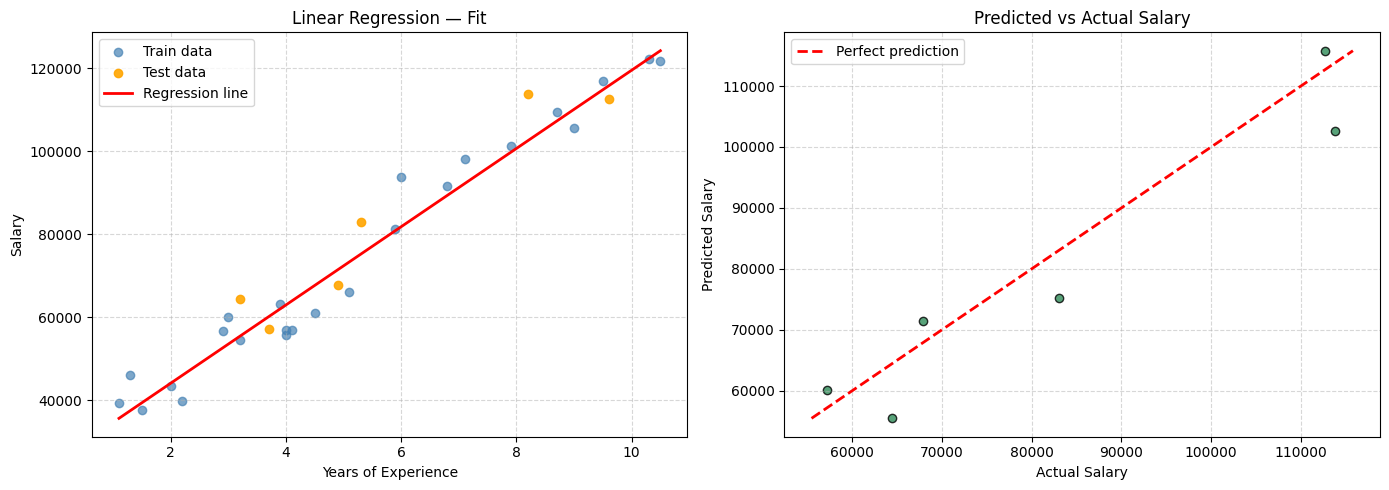

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression line
axes[0].scatter(X_train, y_train, color='steelblue', alpha=0.7, label='Train data')
axes[0].scatter(X_test,  y_test,  color='orange',    alpha=0.9, label='Test data')
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary')
axes[0].set_title('Linear Regression — Fit')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Predicted vs Actual
axes[1].scatter(y_test, y_pred, color='seagreen', alpha=0.8, edgecolors='black')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title('Predicted vs Actual Salary')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Discussion

The linear regression model is a starting point for predicting salary based on years of experience. This is because the relationship between experience and salary is mostly forward in the range we are looking at. One number tells us how much salary increases with each year of experience. The high R² value means that experience explains most of the differences in salary.
This model is easy to understand and quick to calculate. It lets us make predictions using a basic equation.
However it makes some assumptions that're not entirely accurate. It assumes that salary only depends on experience and nothing else. This ignores factors such as job role, industry, education and location. The model also cannot show how salary growth might slow down after a point.
Overall the linear regression model works as a basic prediction tool but has limitations in capturing the complexity of real-world salary trends and factors.

## Conclusion

In conclusion we were able to use the linear regression model to predict salary from years of experience. The data we used was clean and easy to work with. We found that years of experience is a strong predictor of salary.
We chose to use the Simple Linear Regression model because the relationship between salary and experience is almost linear and it is easy to interpret. We trained the model using Mean Squared Error. We used a method called SVD to find the best parameters. We then evaluated the model using metrics, including MSE, RMSE, MAE and R² and we also looked at the data visually. All of this confirmed that the model is very good at making predictions.
Overall the linear regression model shows that experience is an important factor in determining salary. However if we want to use this model in the world we need to include more factors and use larger more representative datasets to make it more robust and accurate. The linear regression model is a start but it is not enough, on its own. We need to add features to the linear regression model and use bigger datasets to make it better.